In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
pip install ucimlrepo

In [16]:
from ucimlrepo import fetch_ucirepo
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
Y = bank_marketing.data.targets

In [17]:
X.isna().sum() # Verificando valores nulos o basura

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [18]:
X = X.dropna(subset = ["job", "education"]) # Eliminando valores nulos
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN


In [19]:
# Eliminando columnas basura
X = X.drop("contact", axis=1)
X = X.drop("poutcome", axis=1)
X.head()

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0


In [20]:
X.isna().sum() # Revisando la calidad de los datos de nuevo antes de continuar con el analisis

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
day_of_week,0
month,0


In [23]:
datos = X.join(Y)
datos

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0,no
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0,no
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,17,nov,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,17,nov,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,17,nov,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,17,nov,508,4,-1,0,no


In [24]:
Y = datos[['y']]
Y

,y
0,no
1,no
2,no
5,no
6,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [25]:
X = datos.drop("y", axis=1)
X

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,17,nov,977,3,-1,0
45207,71,retired,divorced,primary,no,1729,no,no,17,nov,456,2,-1,0
45208,72,retired,married,secondary,no,5715,no,no,17,nov,1127,5,184,3
45209,57,blue-collar,married,secondary,no,668,no,no,17,nov,508,4,-1,0


In [26]:
X = pd.get_dummies(X, columns=['job', 'marital'])
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,tertiary,no,2143,yes,no,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,secondary,no,29,yes,no,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,secondary,no,2,yes,yes,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,tertiary,no,231,yes,no,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,tertiary,no,447,yes,yes,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,tertiary,no,825,no,no,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,primary,no,1729,no,no,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,secondary,no,5715,no,no,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,secondary,no,668,no,no,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [31]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

In [32]:
X.loc[:,"default"] = encoder.fit_transform(X[["default"]])
X.loc[:,"housing"] = encoder.fit_transform(X[["housing"]])
X.loc[:,"loan"] = encoder.fit_transform(X[["loan"]])
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,tertiary,0.0,2143,1.0,0.0,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,secondary,0.0,29,1.0,0.0,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,secondary,0.0,2,1.0,1.0,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,tertiary,0.0,231,1.0,0.0,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,tertiary,0.0,447,1.0,1.0,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,tertiary,0.0,825,0.0,0.0,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,primary,0.0,1729,0.0,0.0,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,secondary,0.0,5715,0.0,0.0,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,secondary,0.0,668,0.0,0.0,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [33]:
map_dict = {"primary":1, "secondary":2, "tertiary":3}
X["education"] = X["education"].map(map_dict)
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,3,0.0,2143,1.0,0.0,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,2,0.0,29,1.0,0.0,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,2,0.0,2,1.0,1.0,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,3,0.0,231,1.0,0.0,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,3,0.0,447,1.0,1.0,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0.0,825,0.0,0.0,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,1,0.0,1729,0.0,0.0,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,2,0.0,5715,0.0,0.0,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,2,0.0,668,0.0,0.0,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [34]:
map_dict = {"jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12}
X["month"] = X["month"].map(map_dict)
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,3,0.0,2143,1.0,0.0,5,5,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,2,0.0,29,1.0,0.0,5,5,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,2,0.0,2,1.0,1.0,5,5,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,3,0.0,231,1.0,0.0,5,5,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,3,0.0,447,1.0,1.0,5,5,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0.0,825,0.0,0.0,17,11,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,1,0.0,1729,0.0,0.0,17,11,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,2,0.0,5715,0.0,0.0,17,11,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,2,0.0,668,0.0,0.0,17,11,508,4,...,False,False,False,False,False,False,False,False,True,False


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((34554, 26), (8639, 26), (34554, 1), (8639, 1))

In [41]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
pd.DataFrame(model.get_params().items())

,0,1
0,ccp_alpha,0.0
1,class_weight,None
2,criterion,gini
3,max_depth,None
4,max_features,None
5,max_leaf_nodes,None
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,2
9,min_weight_fraction_leaf,0.0


In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [46]:
cm = confusion_matrix(Y_test, y_pred)
cm

array([[7085,  573],
       [ 502,  479]])

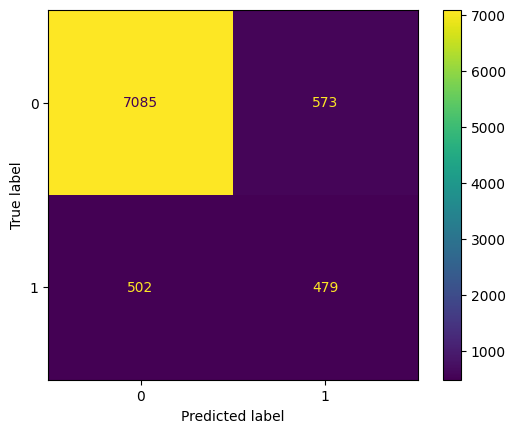

In [48]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [51]:
# precision de los datos
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.875564301423776

In [50]:
X.shape, Y.shape

((43193, 26), (43193, 1))

In [52]:
datos = X.join(Y)
datos.shape

(43193, 27)

In [ ]:
# Balanceo de datos

In [59]:
datos_true = datos[datos.y == "yes"]
datos_true.shape

(5021, 27)

In [60]:
datos_false = datos[datos.y == "no"]
datos_false.shape

(38172, 27)

In [61]:
datos_false = datos_false.sample(n = len(datos_true))
datos_false.shape

(5021, 27)

In [64]:
datos = pd.concat([datos_true, datos_false])
datos = datos.reset_index(drop=True)
datos.shape

(10042, 27)

In [65]:
datos.sample(n = 10)

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,y
8423,45,1,0.0,749,1.0,0.0,15,5,242,6,...,False,False,False,False,False,False,True,False,False,no
1372,32,1,0.0,634,0.0,0.0,29,1,696,1,...,False,False,False,False,False,False,False,True,False,yes
3575,61,3,0.0,2557,1.0,0.0,10,11,89,1,...,True,False,False,False,False,False,False,True,False,yes
1789,35,2,0.0,16,1.0,0.0,8,4,903,1,...,False,False,False,False,True,False,False,False,True,yes
2072,49,2,0.0,3608,1.0,0.0,30,4,252,1,...,False,False,False,False,False,False,False,True,False,yes
7777,48,2,0.0,194,1.0,1.0,12,5,290,6,...,False,False,True,False,False,False,False,True,False,no
7989,31,2,0.0,1661,1.0,0.0,11,7,100,2,...,False,False,False,False,False,False,False,True,False,no
3553,76,1,0.0,1492,0.0,0.0,3,11,383,1,...,True,False,False,False,False,False,False,True,False,yes
8835,54,3,0.0,397,1.0,0.0,11,5,102,1,...,False,False,False,False,False,False,False,True,False,no
3063,32,3,0.0,935,0.0,0.0,10,8,161,2,...,False,False,False,False,False,False,False,False,True,yes
